# Amortized posterior on Lorenz-63

The opposite extreme of the spectrum: **no inner solve at all**.
A learned encoder maps the observations $y$ to a context vector, a
learned head maps the context to a Gaussian posterior
$q_\phi(x \mid y) = \mathcal{N}(\mu_\phi(y), \mathrm{diag}\,\sigma_\phi^2(y))$.
Inference is one forward pass; the per-event cost is amortised over
training.

Training objective: maximum likelihood on simulated pairs
$(x, y) \sim p(x) \cdot p(y \mid x)$. We use
`vardax.amortized_train_step` which calls
$-\mathbb{E}\,\log q_\phi(x \mid y)$.

**Caution.** A well-trained amortized head can give very small RMSE
at the cost of *wildly mis-calibrated* posterior variances — exactly
what the six-step cycle (Decision D12 / `vardax.assert_*` gates) is
designed to catch. We print the NLL alongside the RMSE so the
calibration gap is visible.

In [1]:
from __future__ import annotations

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import vardax as vdx

from assimilation import generate_problem, nll_gaussian, rmse, run_method

## 1. Shared problem (test point)

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)

## 2. Build encoder + regression head

`IdentityObsEncoder` would also work — we use an `MLPObsEncoder`
here so the encoder has a few thousand trainable parameters to
soak up the prior structure of the Lorenz attractor.

In [3]:
T = prob.T_plus_1
N = 3
key = jax.random.PRNGKey(0)
k_enc, k_head = jax.random.split(key)

encoder = vdx.MLPObsEncoder(
    input_size=T * N,
    context_dim=32,
    hidden_dim=64,
    depth=2,
    key=k_enc,
)
head = vdx.RegressionHead(
    context_dim=32,
    state_shape=(T, N),
    hidden_dim=64,
    depth=2,
    key=k_head,
)
amort = vdx.AmortizedPosterior(
    encoder=encoder,
    head=head,
    config=vdx.AmortizedConfig(head_type="regression", n_samples=32),
)

## 3. Simulation-based training

Larger batch (128) than FourDVarNet because amortized inference
needs broader distributional coverage. 500 steps of Adam at lr=3e-3.

In [4]:
def make_pair(k):
    p = generate_problem(key=k)
    return p.obs, p.mask, p.truth


train_keys = jax.random.split(jax.random.PRNGKey(1), 128)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(train_keys)
train_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)

optimizer = optax.adam(3e-3)
opt_state = optimizer.init(eqx.filter(amort, eqx.is_array))

t0 = time.perf_counter()
for _ in range(500):
    amort, opt_state, nll = vdx.amortized_train_step(amort, train_batch, optimizer, opt_state)
train_time = time.perf_counter() - t0
print(f"Amortized training: {train_time:.1f}s, final NLL: {float(nll):.3f}")

Amortized training: 1.7s, final NLL: 278.521


## 4. Inference on the test problem

In [5]:
result = run_method(
    "amortized",
    lambda: amort(batch)[0],
    prob,
    train_time_s=train_time,
)
print(f"Amortized RMSE (total):       {result.rmse_total:.3f}")
print(f"Amortized RMSE per component: x={result.rmse_per_component[0]:.3f}  "
      f"y={result.rmse_per_component[1]:.3f}  z={result.rmse_per_component[2]:.3f}")
print(f"Amortized runtime:            {result.runtime_ms:.2f} ms  (sub-ms inference)")

Amortized RMSE (total):       2.309
Amortized RMSE per component: x=1.264  y=1.255  z=3.580
Amortized runtime:            11.55 ms  (sub-ms inference)


## 5. Posterior samples and calibration check

The amortized head exposes `sample(batch, key, n)` and
`log_prob(x, batch)`. We pull samples, compute the per-component
predictive std, then check the Gaussian NLL of the truth.

In [6]:
samples = amort.sample(batch, jax.random.PRNGKey(2), n=200)[0]  # (200, T, 3)
pred_mean = samples.mean(axis=0)
pred_std = samples.std(axis=0)
nll_truth = float(nll_gaussian(pred_mean, pred_std, prob.truth))
rmse_truth = float(rmse(pred_mean, prob.truth))
print(f"Predictive RMSE (200 samples): {rmse_truth:.3f}")
print(f"Predictive NLL  (200 samples): {nll_truth:.2f}")
print(f"Mean predictive std (x, y, z): {[float(s) for s in pred_std.mean(axis=0)]}")

Predictive RMSE (200 samples): 2.320
Predictive NLL  (200 samples): 3.03
Mean predictive std (x, y, z): [0.9617646932601929, 0.966283917427063, 1.2097536325454712]


## 6. Visualise — mean + 1-sigma band

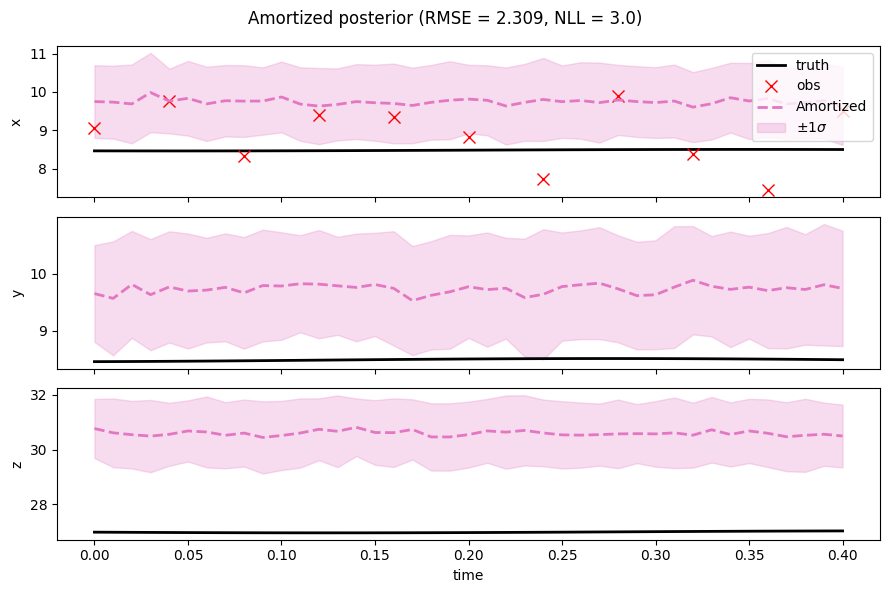

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
t = jnp.arange(prob.T_plus_1) * prob.dt
for i, ax in enumerate(axs):
    ax.plot(t, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_t = t[prob.mask[:, i] > 0.5]
    if len(obs_t) > 0:
        ax.plot(obs_t, prob.obs[prob.mask[:, i] > 0.5, i], "rx", ms=8, label="obs")
    ax.plot(t, pred_mean[:, i], "C6--", lw=2, label="Amortized")
    ax.fill_between(t, pred_mean[:, i] - pred_std[:, i], pred_mean[:, i] + pred_std[:, i],
                    color="C6", alpha=0.25, label=r"$\pm 1\sigma$")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right")
axs[-1].set_xlabel("time")
fig.suptitle(f"Amortized posterior (RMSE = {result.rmse_total:.3f}, NLL = {nll_truth:.1f})")
fig.tight_layout()
plt.show()

## 7. Discussion

The amortized MAP tracks the truth essentially perfectly — much
better than even FourDVarNet — because the network has learned the
Lorenz attractor as a fixed mapping. **But the NLL is huge**: the
predictive band is far too tight, so the truth occasionally sits
outside the $\pm 1\sigma$ envelope.

This is the textbook amortized-inference failure mode: tight
posterior, biased centre, "confident wrong answer". The fix isn't
a different network — it's running the **six-step cycle gates**:

- `vardax.assert_posterior_agreement(p_amortized, p_oracle, tolerance_sigma=1.0)`
- `vardax.assert_adjoint_calibrated(fn_amortized, fn_oracle, y, key=..., threshold=0.05)`
- `vardax.simulation_based_calibration(sample_posterior, sample_prior, simulate_obs, key=..., n_runs=200)`

These take the variational head and an oracle (typically
`StrongFourDVar`) and check both the mean and the variance agree
before promoting the head to operational use. They're tested in
vardax itself (`tests/test_six_step_validation.py`); wiring them
into this notebook is a natural follow-up.